In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np
import seaborn as sns
import pandas as pd
from ast import literal_eval
from sklearn.manifold import TSNE

In [2]:
all_df = pd.read_csv('/data/wang/junh/results/Fuse_moe/all_los/multiclass/TS_CXR_Text_ECG_test_results.csv')
print(all_df.head())

                ids  Predicted  Ground_Truth  \
0  2769871338191620          2             2   
1  2648608136349817          0             0   
2  2665266630324860          0             2   
3  2731529236478422          1             1   
4  2318286737909743          0             1   

                                               Probs  \
0  [0.023988980799913406, 0.19000543653964996, 0....   
1  [0.6859064102172852, 0.2927089333534241, 0.016...   
2  [0.4659547805786133, 0.4472299814224243, 0.080...   
3  [0.4507652819156647, 0.4543007016181946, 0.082...   
4  [0.5448861718177795, 0.39170101284980774, 0.05...   

                                                Proj  
0  [1.5478515625, 0.075439453125, -1.5029296875, ...  
1  [-1.4443359375, -0.5966796875, -0.1337890625, ...  
2  [-2.1015625, -0.7978515625, -0.873046875, 2.29...  
3  [-1.6474609375, -0.9287109375, -0.48779296875,...  
4  [-1.443359375, -0.7900390625, -1.1328125, 2.33...  


In [3]:
all_df['Proj'] = all_df['Proj'].apply(lambda x: np.array(literal_eval(x)))
all_proj = np.array(all_df['Proj'].values)

In [4]:
ts_proj = []
cxr_proj = []
text_proj = []
ecg_proj = []
proj_4 = []
for proj in all_proj:
    ts_proj.append(proj[0:128])
    cxr_proj.append(proj[128:256])
    text_proj.append(proj[256:384])
    ecg_proj.append(proj[384:512])
    proj_4.append(proj[0:512])

In [5]:
all_df['TS_Proj'] = ts_proj
all_df['CXR_Proj'] = cxr_proj
all_df['Text_Proj'] = text_proj
all_df['ECG_Proj'] = ecg_proj

In [6]:
all_df['flag'] = 1
for i in range(len(all_df)):
    if all_df['Predicted'][i] == all_df['Ground_Truth'][i]:
        all_df['flag'][i] = 0

<ipython-input-6-24c53c991ef3>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df['flag'][i] = 0


In [7]:
print(all_df['flag'].value_counts())

1    468
0    308
Name: flag, dtype: int64


In [8]:
import matplotlib.pyplot as plt
import umap.umap_ as umap
import numpy as np

def plot_umap(modality, modality_proj, ground_truth, n_neighbors=15, min_dist=0.1, random_state=42, title_prefix="UMAP Visualization"):
    """
    Generate and plot a UMAP visualization.

    Parameters:
        modality_proj (np.ndarray): Input feature projections for UMAP.
        ground_truth (array-like): Labels corresponding to the projections.
        n_neighbors (int): Number of neighbors for UMAP (default: 15).
        min_dist (float): Minimum distance between points in the UMAP projection (default: 0.1).
        random_state (int): Random state for consistent UMAP results (default: 42).
        title_prefix (str): Prefix for the plot title (default: "UMAP Visualization").
    """
    # Perform UMAP dimensionality reduction
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)
    embedding = reducer.fit_transform(modality_proj)

    # Define unique classes and colors
    unique_labels = np.unique(ground_truth)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    # Create the scatter plot
    plt.figure(figsize=(10, 8))
    for i, label in enumerate(unique_labels):
        plt.scatter(
            embedding[np.array(ground_truth) == label, 0],
            embedding[np.array(ground_truth) == label, 1],
            color=colors[i],
            label=f'Class {label}',
            alpha=0.8
        )

    # Add legend and labels
    plt.legend(title="Ground Truth", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.title(f"{title_prefix} for {modality}-dimensional features")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(True)

    # Adjust layout and show the plot
    try:
        plt.tight_layout()
    except ValueError:
        plt.subplots_adjust(right=0.8)

    plt.show()

# Example usage (replace with your data)
# plot_umap(modality_proj=ts_proj, ground_truth=all_df['Ground_Truth'])


/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


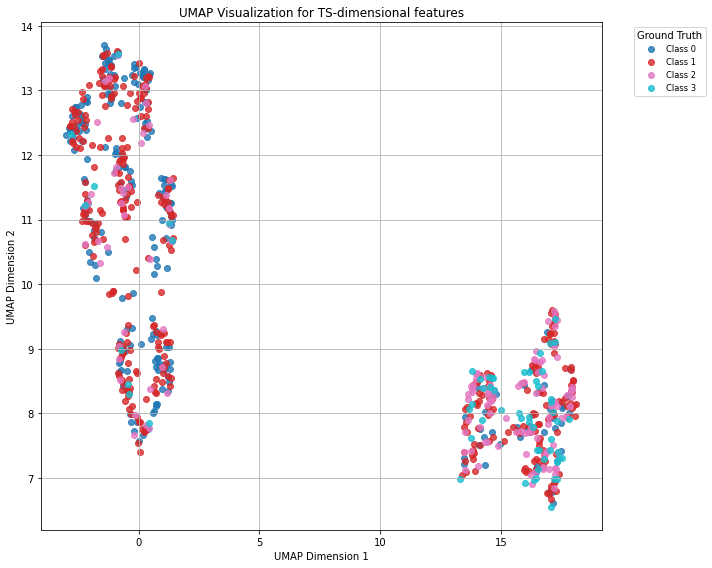

In [9]:
plot_umap('TS', modality_proj=ts_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


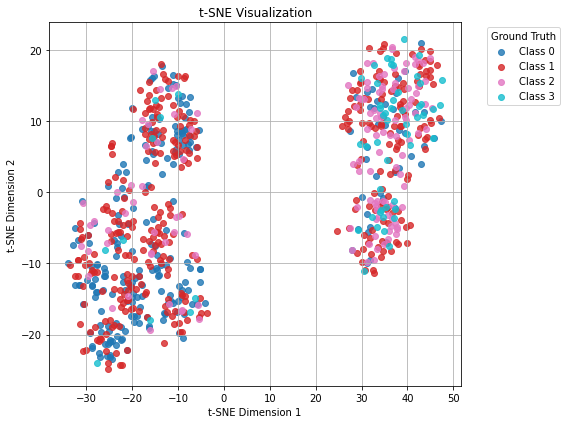

In [82]:
tsne = TSNE(n_components=2, random_state=42)  # Set random_state for consistent results
ts_tsne = tsne.fit_transform(ts_proj)

# Define unique classes and colors
unique_labels = np.unique(all_df['Ground_Truth'])
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))  # Use a colormap for distinct colors

# Create the scatter plot
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    plt.scatter(
        ts_tsne[all_df['Ground_Truth'] == label, 0],
        ts_tsne[all_df['Ground_Truth'] == label, 1],
        color=colors[i],
        label=f'Class {label}',
        alpha=0.8
    )

# Add legend and labels
plt.legend(title="Ground Truth", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()  # Adjust layout to make room for legend
plt.show()

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


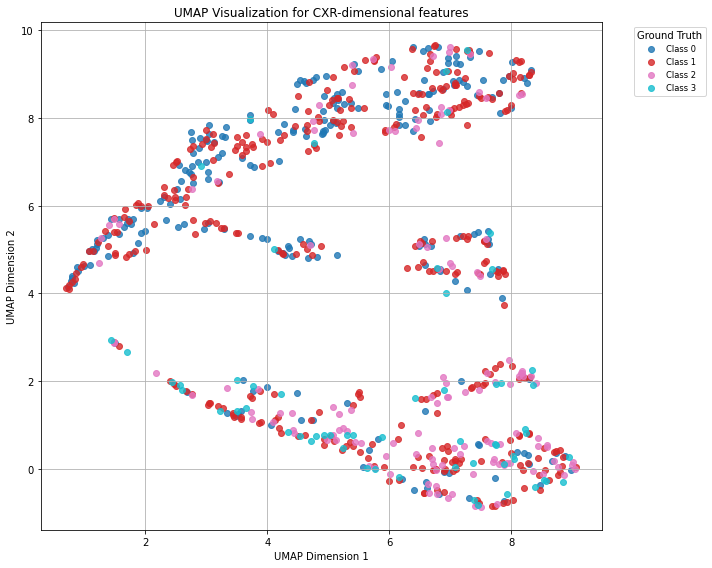

In [10]:
plot_umap('CXR', modality_proj=cxr_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


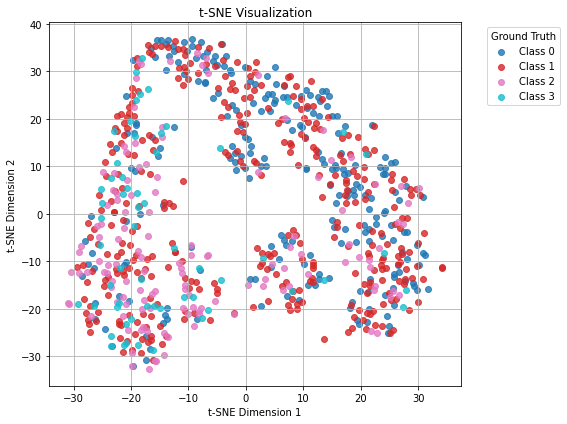

In [86]:
tsne = TSNE(n_components=2, random_state=42)  # Set random_state for consistent results
ts_tsne = tsne.fit_transform(cxr_proj)

# Define unique classes and colors
unique_labels = np.unique(all_df['Ground_Truth'])
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))  # Use a colormap for distinct colors

# Create the scatter plot
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    plt.scatter(
        ts_tsne[all_df['Ground_Truth'] == label, 0],
        ts_tsne[all_df['Ground_Truth'] == label, 1],
        color=colors[i],
        label=f'Class {label}',
        alpha=0.8
    )

# Add legend and labels
plt.legend(title="Ground Truth", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()  # Adjust layout to make room for legend
plt.show()

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


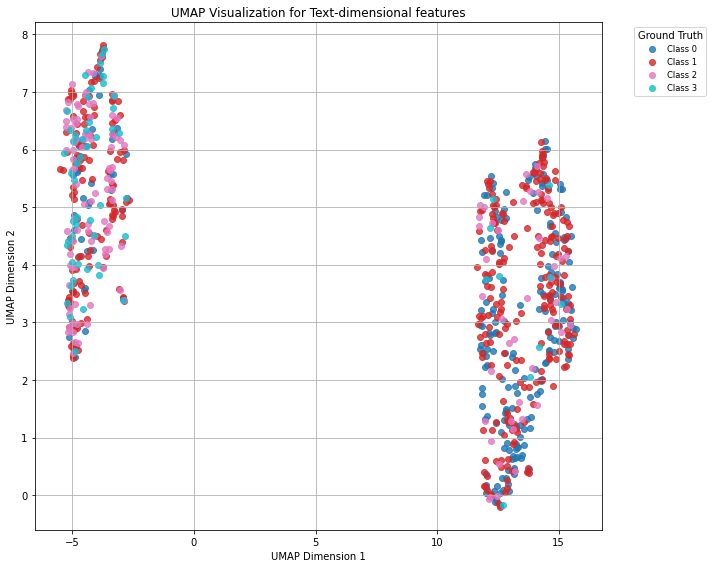

In [11]:
plot_umap('Text', modality_proj=text_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


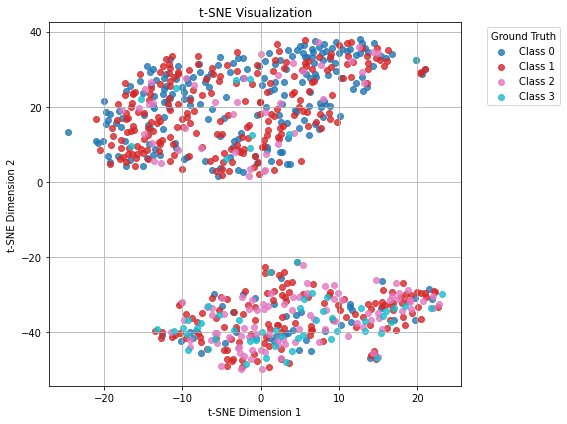

In [87]:
tsne = TSNE(n_components=2, random_state=42)  # Set random_state for consistent results
ts_tsne = tsne.fit_transform(text_proj)

# Define unique classes and colors
unique_labels = np.unique(all_df['Ground_Truth'])
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))  # Use a colormap for distinct colors

# Create the scatter plot
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    plt.scatter(
        ts_tsne[all_df['Ground_Truth'] == label, 0],
        ts_tsne[all_df['Ground_Truth'] == label, 1],
        color=colors[i],
        label=f'Class {label}',
        alpha=0.8
    )

# Add legend and labels
plt.legend(title="Ground Truth", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()  # Adjust layout to make room for legend
plt.show()

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


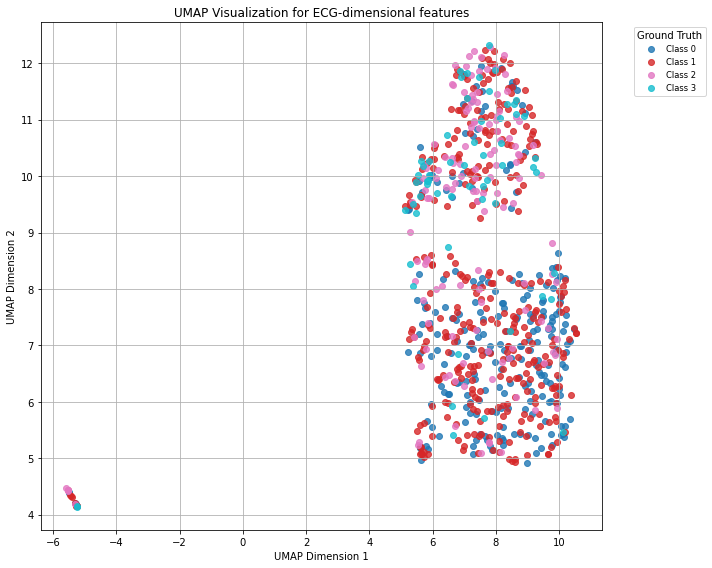

In [12]:
plot_umap('ECG', modality_proj=ecg_proj, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


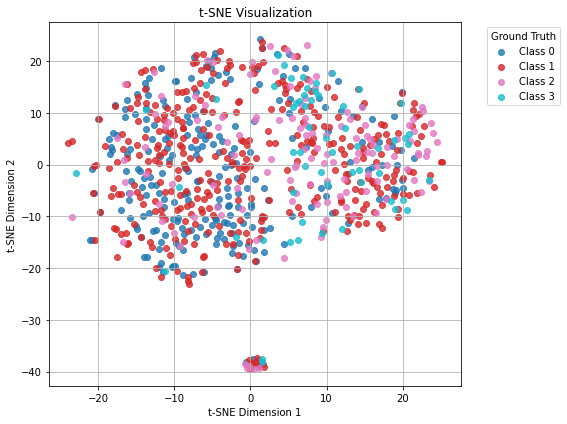

In [88]:
tsne = TSNE(n_components=2, random_state=42)  # Set random_state for consistent results
ts_tsne = tsne.fit_transform(ecg_proj)

# Define unique classes and colors
unique_labels = np.unique(all_df['Ground_Truth'])
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))  # Use a colormap for distinct colors

# Create the scatter plot
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    plt.scatter(
        ts_tsne[all_df['Ground_Truth'] == label, 0],
        ts_tsne[all_df['Ground_Truth'] == label, 1],
        color=colors[i],
        label=f'Class {label}',
        alpha=0.8
    )

# Add legend and labels
plt.legend(title="Ground Truth", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()  # Adjust layout to make room for legend
plt.show()

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


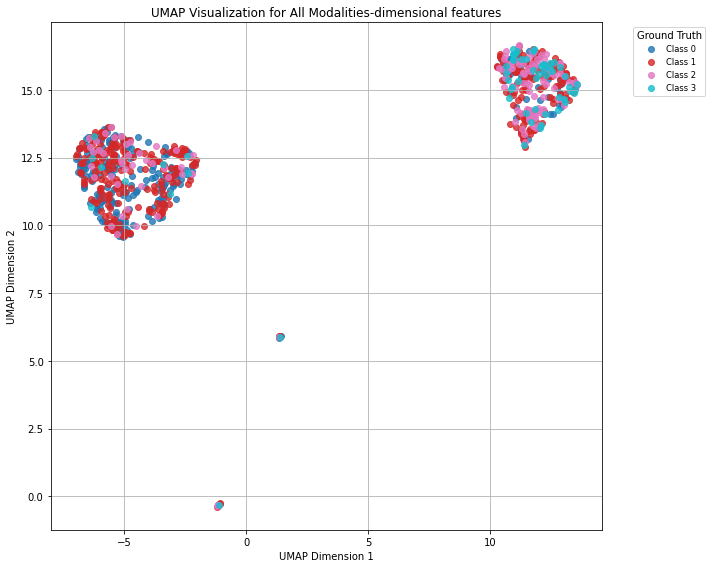

In [13]:
plot_umap('All Modalities', modality_proj=proj_4, ground_truth=all_df['Ground_Truth'])

/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/data/wang/junh/envs/fuse_env/lib/python3.8/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


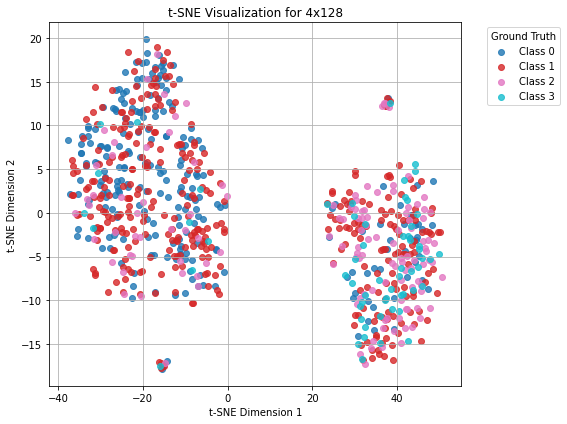

In [85]:
tsne = TSNE(n_components=2, random_state=42)  # Set random_state for consistent results
all_tsne = tsne.fit_transform(proj_4)

# Define unique classes and colors
unique_labels = np.unique(all_df['Ground_Truth'])
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))  # Use a colormap for distinct colors

# Create the scatter plot
plt.figure(figsize=(8, 6))
for i, label in enumerate(unique_labels):
    plt.scatter(
        all_tsne[all_df['Ground_Truth'] == label, 0],
        all_tsne[all_df['Ground_Truth'] == label, 1],
        color=colors[i],
        label=f'Class {label}',
        alpha=0.8
    )

# Add legend and labels
plt.legend(title="Ground Truth", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE Visualization for 4x128")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.tight_layout()  # Adjust layout to make room for legend
plt.show()